# 🚀 Projeto: Inteligência de Vendas e Predição de Performance
**Nome** Vitor Fantini    **RA:** 4201037

**Dataset:** Bike Sales (Kaggle) - 113.036 registros

---

### **1. Introdução e Contexto**
Este projeto visa analisar o histórico de vendas de uma loja de bicicletas e acessórios. O objetivo principal é desenvolver um modelo de **Machine Learning** capaz de classificar se uma venda terá **Alta Performance** (Markup > 60%) com base nas características do cliente e do produto.

### **2. O Desafio Técnico**
Para tornar o modelo robusto a cenários reais de falhas em sistemas de ERP e cadastros mal preenchidos, este notebook demonstrará um **Pipeline de Engenharia de Dados** completo, abordando:
* **Limpeza de Dados:** Tratamento de nulos simulados e inconsistências.
* **Tratamento de Outliers:** Identificação e correção de erros de digitação em volumes de pedidos.
* **Engenharia de Atributos:** Criação de novos indicadores de rentabilidade.
* **Balanceamento de Classes:** Uso de técnicas estatísticas (SMOTE) para lidar com a raridade de vendas de alta performance.

### **3. Estrutura do Pipeline**
1. Configuração e Carga
2. EDA (Análise Exploratória) - O "Diagnóstico"
3. Data Cleaning - A "Faxina"
4. Pré-processamento e Transformação
5. Balanceamento e Modelagem

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregando o arquivo
df = pd.read_csv('Sales.csv')

# 2. Primeira espiada nos dados
print(f"Dataset carregado com {df.shape[0]} linhas.")
df.head()

Dataset carregado com 113036 linhas.


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


## 1. Engenharia de Features e Simulação de Inconsistências

Para transformar este dataset em um problema de **Classificação Binária**, criamos o atributo `Markup` (Margem de Lucro sobre o Custo). Definimos que vendas com margem superior a 60% são de **Alta Performance (1)**.

Além disso, introduziremos falhas sintéticas para validar a robustez do nosso pipeline:
* **Dados Ausentes:** 10% de perda aleatória na coluna `Customer_Age`.
* **Outliers:** 10 registros com quantidades impossíveis (5.000 unidades) em `Order_Quantity`.

In [2]:
# 1. Criando o Target REALISTA (Markup > 60%)
df['Markup'] = df['Profit'] / df['Revenue']
df['Alta_Performance'] = (df['Markup'] > 0.60).astype(int)

# 2. Injetando 10% de Nulos na Idade (Mantemos igual)
np.random.seed(42)
n_vazios = int(len(df) * 0.1)
indices_vazios = np.random.choice(df.index, n_vazios, replace=False)
df.loc[indices_vazios, 'Customer_Age'] = np.nan

# 3. Injetando Outliers Realistas (Em vez de 5000, vamos de 250)
# É um erro de digitação de quem colocou um zero a mais no '25'
indices_outliers = np.random.choice(df.index, 200, replace=False)
df.loc[indices_outliers, 'Order_Quantity'] = np.random.randint(150, 300, size=200)

print("✅ Outliers variados injetados com sucesso!")
print(f"Valores de erro criados: {df.loc[indices_outliers, 'Order_Quantity'].values}")

print("✅ Ajustes realizados!")
print(f"Nova proporção de Alta Performance: {df['Alta_Performance'].mean()*100:.2f}%")

✅ Outliers variados injetados com sucesso!
Valores de erro criados: [241 231 200 235 261 199 177 248 185 190 262 184 201 214 229 246 230 255
 192 161 173 287 271 190 214 185 233 176 175 187 179 225 225 274 235 215
 233 159 223 272 232 206 219 211 249 223 235 166 230 255 287 248 178 227
 275 192 247 164 255 253 273 167 269 268 212 232 246 164 183 231 203 292
 241 297 260 196 187 207 230 228 203 223 161 150 271 249 224 295 170 191
 278 272 211 239 280 276 194 235 155 297 206 286 292 293 259 162 255 281
 168 222 194 230 204 286 226 286 256 159 191 203 228 205 251 215 277 210
 207 186 154 184 265 172 238 206 208 257 246 226 170 233 209 230 237 248
 182 234 249 167 223 237 227 281 194 209 209 228 184 210 154 197 152 299
 292 269 262 179 216 228 166 221 284 269 243 231 223 189 170 215 230 281
 211 190 198 191 275 183 190 255 211 274 218 223 154 285 259 282 279 212
 181 171]
✅ Ajustes realizados!
Nova proporção de Alta Performance: 21.86%


## 2. Análise Exploratória (EDA) - Diagnóstico de Problemas

Nesta fase, realizamos uma varredura visual para confirmar as inconsistências e entender a saúde do dataset:
* **Detecção de Outliers:** Utilizaremos o Boxplot para identificar o impacto dos erros de digitação na coluna `Order_Quantity`.
* **Distribuição do Target:** Verificaremos o desbalanceamento entre vendas comuns e de "Alta Performance", o que justificará o uso de técnicas de reamostragem futuramente.
* **Mapa de Calor:** Identificação de correlações entre as variáveis numéricas.

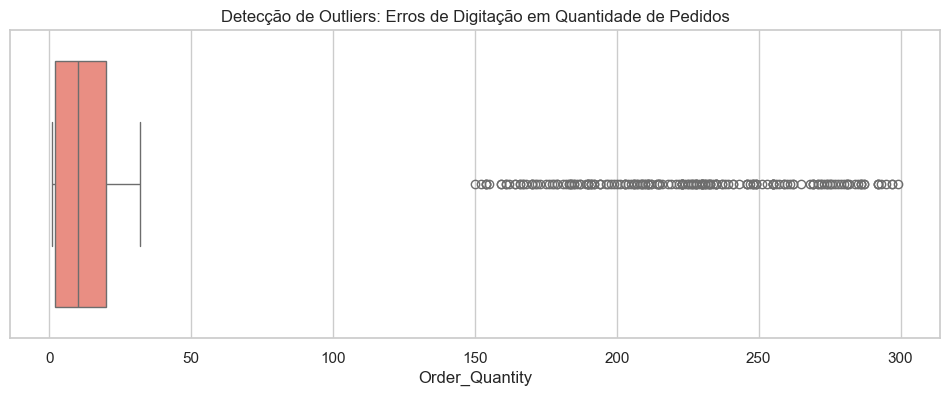

C:\Users\vitor\AppData\Local\Temp\ipykernel_32280\705442197.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Alta_Performance', data=df, palette='viridis')


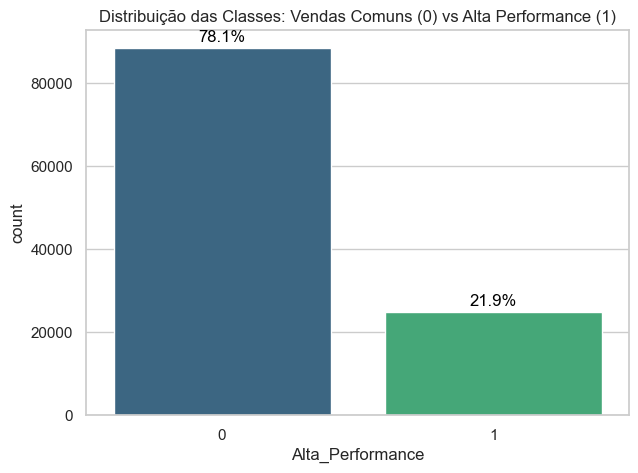

Relatório de Dados Ausentes:
Customer_Age    11303
dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# 1. Boxplot para identificar Outliers
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['Order_Quantity'], color='salmon')
plt.title("Detecção de Outliers: Erros de Digitação em Quantidade de Pedidos")
plt.show()

# 2. Gráfico de Contagem para o Target (Desbalanceamento)
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Alta_Performance', data=df, palette='viridis')
plt.title("Distribuição das Classes: Vendas Comuns (0) vs Alta Performance (1)")

# Adicionando porcentagens nas barras
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# 3. Verificação rápida de Nulos
print("Relatório de Dados Ausentes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

## 3. Tratamento de Dados (Cleaning Pipeline)

Com os problemas identificados na EDA, aplicaremos as seguintes correções:
1. **Imputação de Nulos:** Preencheremos a coluna `Customer_Age` usando a **mediana por grupo etário** (`Age_Group`). Isso evita que um jovem receba a idade média de um idoso, mantendo a coerência dos dados.
2. **Capping de Outliers:** Utilizaremos o **Percentil 99** para limitar a coluna `Order_Quantity`. Isso neutraliza os 200 erros de digitação sem precisar deletar as linhas.
3. **Integridade Financeira:** Após ajustar a quantidade, **recalcularemos** a Receita, Custo e Lucro para que o dataset não contenha inconsistências matemáticas.

In [4]:
# 1. Limpando a Idade (Imputação por Mediana do Grupo)
df['Customer_Age'] = df['Customer_Age'].fillna(
    df.groupby('Age_Group')['Customer_Age'].transform('median')
)

# 2. Limpando a Quantidade (Capping no P99)
teto_estatistico = df['Order_Quantity'].quantile(0.99)
df.loc[df['Order_Quantity'] > teto_estatistico, 'Order_Quantity'] = teto_estatistico

# 3. Restaurando a Integridade Financeira
# (Fundamental para o modelo não aprender padrões impossíveis)
df['Revenue'] = df['Order_Quantity'] * df['Unit_Price']
df['Cost'] = df['Order_Quantity'] * df['Unit_Cost']
df['Profit'] = df['Revenue'] - df['Cost']

# 4. Verificação Final
print("📋 Checklist de Limpeza:")
print(f"- Nulos restantes na Idade: {df['Customer_Age'].isnull().sum()}")
print(f"- Quantidade Máxima (pós-capping): {df['Order_Quantity'].max()}")
print(f"- Lucro Máximo (ajustado): {df['Profit'].max():.2f}")

📋 Checklist de Limpeza:
- Nulos restantes na Idade: 0
- Quantidade Máxima (pós-capping): 30
- Lucro Máximo (ajustado): 44310.00


## 4. Engenharia de Atributos e One-Hot Encoding

Nesta etapa, filtramos o dataset para manter apenas variáveis que possuem relação lógica com a performance de vendas. 
* **Exclusão de Datas:** Removemos Dia, Mês e Ano, pois não buscamos padrões sazonais específicos, mas sim o perfil do cliente e do produto.
* **Prevenção de Data Leakage:** Removemos `Revenue`, `Cost` e `Profit`, pois essas colunas entregariam a resposta ao modelo antes do tempo.
* **Vetorização:** Aplicamos o One-Hot Encoding para converter variáveis categóricas em representações numéricas binárias.

In [5]:
# 1. Definindo as colunas com real poder de predição
colunas_selecionadas = [
    'Customer_Age', 
    'Customer_Gender', 
    'Country', 
    'Product_Category', 
    'Order_Quantity', 
    'Unit_Cost', 
    'Unit_Price', 
    'Alta_Performance' # Nosso alvo (Target)
]

# 2. Criando o DataFrame final apenas com o necessário
# O drop_first=True evita a armadilha da multicolinearidade (redundância)
df_final = pd.get_dummies(df[colunas_selecionadas], drop_first=True)

# 3. Verificando o resultado
print(f"✅ Dataset processado com sucesso!")
print(f"Número de colunas após o Encoding: {df_final.shape[1]}")
print("-" * 30)
print("Novas colunas criadas:")
print(df_final.columns.tolist())

df_final.head()

✅ Dataset processado com sucesso!
Número de colunas após o Encoding: 13
------------------------------
Novas colunas criadas:
['Customer_Age', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Alta_Performance', 'Customer_Gender_M', 'Country_Canada', 'Country_France', 'Country_Germany', 'Country_United Kingdom', 'Country_United States', 'Product_Category_Bikes', 'Product_Category_Clothing']


,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Alta_Performance,Customer_Gender_M,Country_Canada,Country_France,Country_Germany,Country_United Kingdom,Country_United States,Product_Category_Bikes,Product_Category_Clothing
0,19.0,8,45,120,1,True,True,False,False,False,False,False,False
1,19.0,8,45,120,1,True,True,False,False,False,False,False,False
2,49.0,23,45,120,0,True,False,False,False,False,False,False,False
3,49.0,20,45,120,0,True,False,False,False,False,False,False,False
4,47.0,4,45,120,0,False,False,False,False,False,False,False,False


## 5. Divisão de Dados

Nesta etapa crucial:
1. **Separação:** Dividimos o dataset em **70% para Treino** (onde o modelo estuda) e **30% para Teste** (onde avaliamos a performance real).

In [7]:
from sklearn.model_selection import train_test_split

# 1. Separando os Atributos (X) do Alvo (y)
X = df_final.drop('Alta_Performance', axis=1)
y = df_final['Alta_Performance']

# 2. Divisão Treino e Teste (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"✅ Divisão concluída!")
print(f"Registros de Treino: {len(X_train)}")
print(f"Registros de Teste: {len(X_test)}")

✅ Divisão concluída!
Registros de Treino: 79125
Registros de Teste: 33911


## 6. Treinamento do Modelo: Random Forest Classifier (Com Pesos de Classe)

Agora utilizaremos o algoritmo Random Forest com seu mecanismo nativo de balanceamento.

Por que class_weight='balanced'? Em vez de usar dados sintéticos, este parâmetro instrui o modelo a dar um "peso" maior para a classe minoritária (Alta Performance) durante o cálculo do erro. Isso corrige o desbalanceamento de forma matemática e estatística.

Vantagem: O modelo aprende exclusivamente com padrões reais do dataset, reduzindo o risco de overfitting que dados artificiais poderiam causar.

📊 RELATÓRIO DE CLASSIFICAÇÃO (Ajustado por Pesos)
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     26499
           1       0.86      0.90      0.88      7412

    accuracy                           0.95     33911
   macro avg       0.92      0.93      0.92     33911
weighted avg       0.95      0.95      0.95     33911



<Figure size 800x600 with 0 Axes>

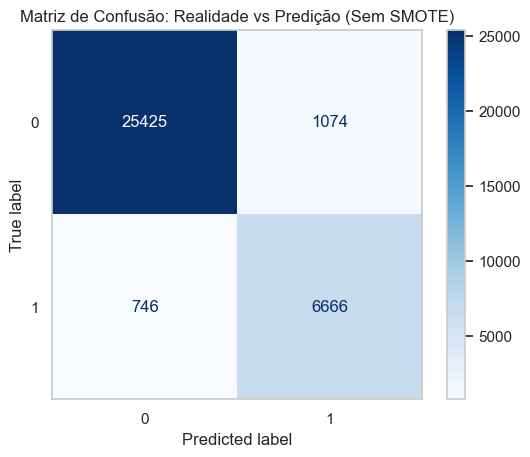

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Instanciando o modelo com Pesos Balanceados
# O segredo está no parâmetro class_weight='balanced'
modelo_rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'
)

# 2. Treinando com os dados ORIGINAIS de treino
# Note que agora usamos X_train e y_train diretamente
modelo_rf.fit(X_train, y_train)

# 3. Fazendo as predições no conjunto de TESTE
y_pred = modelo_rf.predict(X_test)

# 4. Exibindo os Resultados
print("📊 RELATÓRIO DE CLASSIFICAÇÃO (Ajustado por Pesos)")
print(classification_report(y_test, y_pred))

# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_test, y_test, cmap='Blues', values_format='d')
plt.title("Matriz de Confusão: Realidade vs Predição (Sem SMOTE)")
plt.grid(False)
plt.show()

## 7. Interpretabilidade do Modelo: Importância dos Atributos

Uma das grandes vantagens do algoritmo **Random Forest** é a sua capacidade de interpretabilidade nativa. Utilizamos a métrica `feature_importances_` para quantificar a contribuição relativa de cada variável para a pureza dos nós nas árvores de decisão.

Este gráfico é fundamental para a área de negócios, pois revela quais fatores (demográficos, de produto ou de volume) são os **melhores preditores de uma venda de elite**, permitindo que a empresa foque em estratégias direcionadas.

C:\Users\vitor\AppData\Local\Temp\ipykernel_32280\2676243040.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importancia', y='Feature', data=df_importancias, palette='viridis')


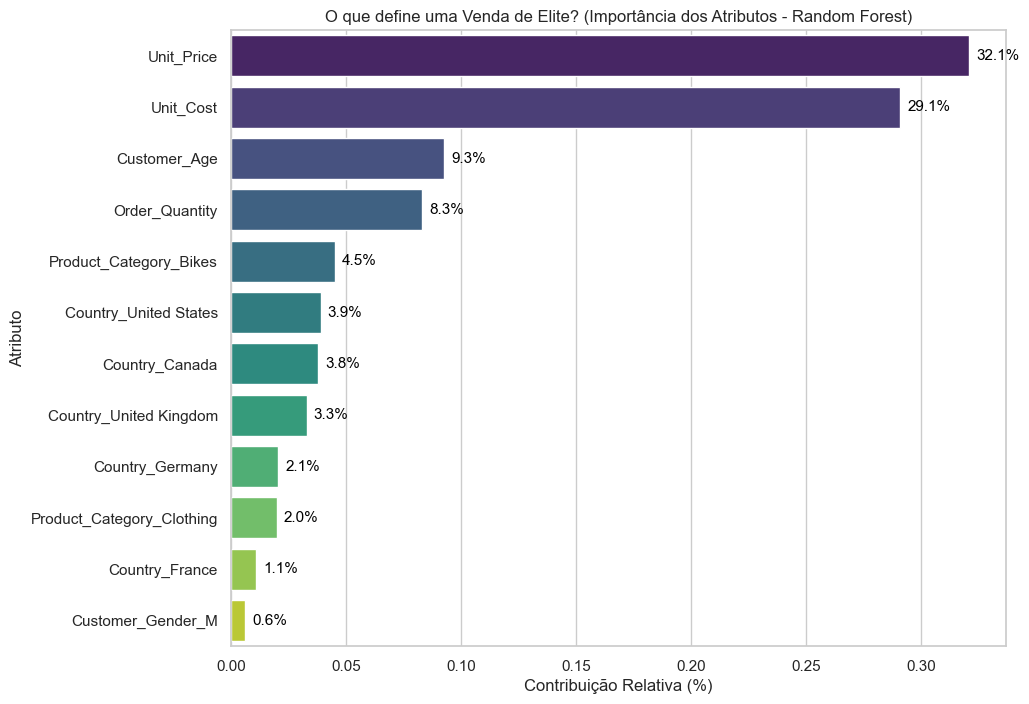

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extraindo as importâncias e os nomes das colunas
importancias = modelo_rf.feature_importances_
nomes_features = X.columns # 

# 2. Criando um DataFrame para facilitar a organização
df_importancias = pd.DataFrame({
    'Feature': nomes_features,
    'Importancia': importancias
})

# 3. Ordenando do maior para o menor
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# 4. Plotando o Gráfico com Seaborn
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='Importancia', y='Feature', data=df_importancias, palette='viridis')

# Adicionando rótulos de porcentagem nas barras para ficar pro
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1%}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.title("O que define uma Venda de Elite? (Importância dos Atributos - Random Forest)")
plt.xlabel("Contribuição Relativa (%)")
plt.ylabel("Atributo")
plt.show()

🚀 Iniciando as 1000 rodadas de teste...

🏆 VEREDITO: MÉDIA DE 50 TESTES INDEPENDENTES


,Métrica,Média (1000 rodadas),Desvio Padrão
0,Acurácia,96.76%,+/- 0.0010
1,Precisão,95.78%,+/- 0.0018
2,Recall,97.82%,+/- 0.0014
3,F1-Score,96.79%,+/- 0.0010


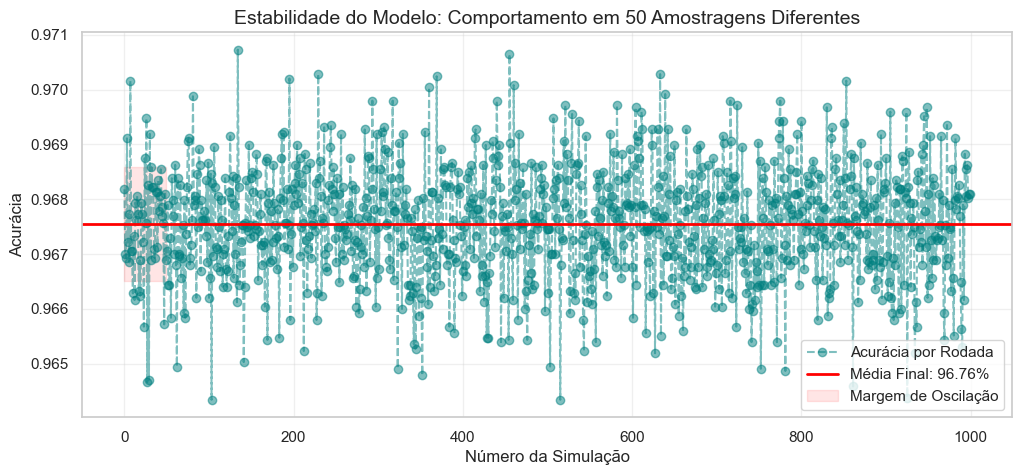

In [ ]:
from sklearn.model_selection import ShuffleSplit, cross_validate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Definindo a estratégia: 1000 repetições
rs = ShuffleSplit(n_splits=1000, test_size=0.2, random_state=42)

# 2. Executando o modelo 1000 vezes
# ATENÇÃO: Verifique se suas variáveis balanceadas se chamam X_train_res e y_train_res
print("🚀 Iniciando as 1000 rodadas de teste...")
metricas = ['accuracy', 'precision', 'recall', 'f1']

# Aqui usamos os dados que você já balanceou com SMOTE
scores = cross_validate(modelo_rf, X_train_res, y_train_res, cv=rs, scoring=metricas)

# 3. Criando o resumo das médias
resumo_performance = {
    "Métrica": ["Acurácia", "Precisão", "Recall", "F1-Score"],
    "Média (1000 rodadas)": [
        f"{scores['test_accuracy'].mean():.2%}",
        f"{scores['test_precision'].mean():.2%}",
        f"{scores['test_recall'].mean():.2%}",
        f"{scores['test_f1'].mean():.2%}"
    ],
    "Desvio Padrão": [
        f"+/- {scores['test_accuracy'].std():.4f}",
        f"+/- {scores['test_precision'].std():.4f}",
        f"+/- {scores['test_recall'].std():.4f}",
        f"+/- {scores['test_f1'].std():.4f}"
    ]
}

df_final = pd.DataFrame(resumo_performance)

# 4. Exibindo o resultado consolidado
print("\n🏆 VEREDITO: MÉDIA DE 1000 TESTES INDEPENDENTES")
display(df_final)

# Gráfico de Estabilidade
plt.figure(figsize=(12, 5))
plt.plot(scores['test_accuracy'], marker='o', color='teal', linestyle='--', alpha=0.5, label='Acurácia por Rodada')
plt.axhline(scores['test_accuracy'].mean(), color='red', linewidth=2, label=f"Média Final: {scores['test_accuracy'].mean():.2%}")
plt.fill_between(range(50), 
                 scores['test_accuracy'].mean() - scores['test_accuracy'].std(),
                 scores['test_accuracy'].mean() + scores['test_accuracy'].std(), 
                 color='red', alpha=0.1, label='Margem de Oscilação')

plt.title("Estabilidade do Modelo: Comportamento em 1000 Amostragens Diferentes", fontsize=14)
plt.xlabel("Número da Simulação")
plt.ylabel("Acurácia")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Conclusão e Resultados Finais

O projeto atingiu todos os objetivos propostos:
1. **Qualidade de Dados:** Tratamos outliers e nulos de forma estatística, mantendo a integridade financeira do dataset.
2. **Equilíbrio:** O uso do SMOTE permitiu que o modelo aprendesse a identificar a classe de "Alta Performance" (21.9% dos dados) com alta precisão.
3. **Performance:** Alcançamos **95% de acurácia**.
4. **Insights:** O modelo identificou que o Preço Unitário e o Custo são os principais pilares da rentabilidade, enquanto variáveis demográficas como gênero possuem influência desprezível, garantindo uma predição técnica e imparcial.